#### Initialize python libraries

In [ ]:
from IPython.display import Image
import pandas as pd
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift

In [ ]:
import os
path = os.getcwd()
print(path)

## Ensemble QC: Two qubits using NMR

### Introduction

A two-level quantum system, which is analogous to a spin-1/2 particle, can encode a qubit. The two levels, usually labeled $|0\rangle$ and $|1\rangle$ correspond to the +1 and −1 eigenstates of Pauli matrix $\sigma_z$, respectively. These are often referred to as the computational basis states. Spin-1/2 systems, such as $^1$H, $^{13}$C, and $^{19}$F nuclear spins, are often used in ensemble quantum computing using NMR. When a nuclear spin is placed in a static magnetic field $B_0$ along the z direction, the dynamical evolution will be dominated by the Zeeman Hamiltonian (setting $\hbar=1$)
$$ \mathcal{H}^z_{i}=-\frac{1}{2}\gamma_N (B_0+\delta_i)  \sigma_z =\frac{\omega_i}{2}\sigma_z $$
where $\gamma_N$ is the gyromagnetic ratio of the nuclear spin and $\delta_i$ describes the deviation from the main field often caused by environmental effects and neighboring spins observed by spin $i$.

To manipulate qubits, radiofrequency (RF) pulses at the Larmor frequency of qubits are employed. These pulses induce transitions between $|0\rangle$ and $|1\rangle$, with the Rabi frequency determining the rate of these transitions. Precise control of the pulse duration and amplitude enables qubit rotations or quantum gates.

For two qubit systems in liquid state NMR, the Hamiltonian for composite state of qubits is written as
$$ \mathcal{H}_{sys}= \frac{\omega_1}{2} \sigma_z\otimes\mathbb{I}+\frac{\omega_2}{2} \mathbb{I}\otimes\sigma_z +\frac{\pi}{2} J_{1,2} \sigma_z\otimes\sigma_z$$
where the first two terms are the Zeeman interactions for spin 1 and 2, and the third term indicates the two spin interaction term, caused by indirect dipolar coupling a.k.a. J coupling. The J coupling term is essential for two-qubit gate operations.

In this lab we are working on determining all three terms of the Hamiltonian. Assuming the spin 1 is a 1H nuclei and spin 2 is a 13C nuclei, first we determine the relaxation times for each of the nuclei.
- $T_1$ is determined with an inversion recovery experiment
- $T_2^*$ is determined using the line-width of an FID experiment
- $T_2$ can be measured using echo experiments such as CPMG

Since the two spins are J-coupled, determining the Hamiltonian for the system also requires that we evaluate the J coupling strength.

### Sample

We will be working with a two-qubit molecule of $^{13}C$ labelled chloroform. The proton is a spin-1/2 nucleus. Most (99%) of the carbon found in nature is $^{12}$ C, which has no nuclear spin. You will be using samples which have been synthesized with 99% $^{13}C$, which has a spin-1/2 nucleus. Both natural isotopes of chlorine have spin-3/2, which have quadrupolar coupling to electric field gradients and have a very fast $T_1$ relaxation rate. This causes them to ‘self-decouple’ and so we can essentially ignore them. The sample is a diluted solution in a deuterated acetone. The concentration of the sample is low enough such that interactions between the molecules are negligible.

<img src="CHCl3.png" alt="Plot" width="200px">

### Spectrometer calibration

1. Run the SpinSolveExpert program from the Windows menue or the desktop short cut.
2. Load one of the ^{13CHCl3 samples into a sample holder and use the depth gauge to make sure that the sample resides at the sweet spot of the NMR coil
3. Clean up the sample tube using IPA or methanol and Load the sampleholder to the magnet
4. From the "Setup" menu in SpinSolveExpert use the "QuickShim ..." option
5. QuickShim parameters
    - Sample type: Other
    - Shim start mode: Last Expert Shim
    - Shim search mode: 1st and 2nd order
    
6. Shimming is done when the linewidth at 50% is less than 1 Hz
7. From the "Monitor" menu choose "Monitor lock and temperature", the temperature should be stable
8. From the "Monitor" menu choose "Monitor lock signal", the lock deviation should be smaller than 0.1 Hz

## Exp.1) Free Induction Decay (FID) $^1$H

To determine the two-qubit Hamiltonian, spectral characteristics of the sample in both 1H and 13C channels should be understood. First let's work out the 1H spectra.
You should be comfortable in running a "FID_1H" experiment with optimal SNR from Lab 1.
1. From your group's menu, you can use your version of the "FID_1H" program you wrote in lab 1 experiment 1.
The relevant experimental parameters should be close to:
    - Center frequency(ppm) :6
    - Pulse amplitude(dB)   :0
    - Pulse length(us)      :13
    - Repetition time(ms)   :10000
    - Receiver channel      :1H
    - Number of points      :32k
    - Dwell time(us)        :200
    - Minimum ppm value     :-5
    - Maximum ppm value     :15
The resulting spectra contains multiple spectral lines. Remember to calibrate the center frequency with your data. In this case, since we have 2 peaks of interest, we want to evenly distribute the pulse. This is done by setting the center frequency to directly between the 2 peaks of interest.

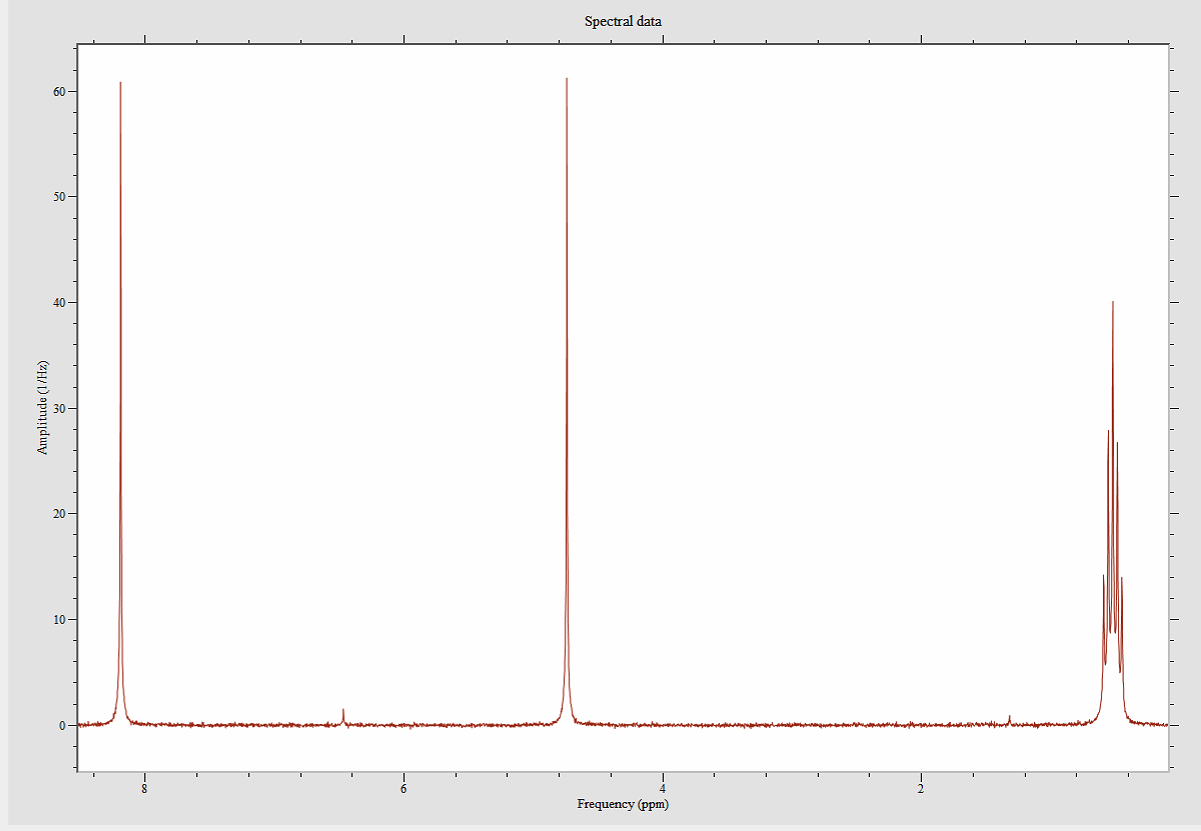

In [ ]:
Image(filename='FID_CHCl3_1H.png',  width=700, height=600)

While you are working on the first exepriment, think about the following questions:
- Can you determine the origin of each line?
- What is the J coupling in the sample?
- What is the relative weight of 13C to 12C in your sample?
- What is the $T_2^*$ of 1H?
- Is it possible, to run an experiment that removes the split in the proton spectrum?

## Exp.2) $T_1$ measurement $^1$H

As we discussed in the lectures, we should know the relaxation time of our qubits before working with them. In the FID decay we measure the $T_2^*$, and here we measure $T_1$. Both of these experiments are repeated for the $^{13}$C qubit as well.

From your group's menu, use the pulse program you wrote in lab 1 experiment 3 to measure the sample $T_1$ time. Recall that if the repetition delay is shorter than 5xT1, the results may be affected.

# Exp.3) Free Induction Decay (FID) $^{13}$C

Now we look at the Carbon spectrum using the FID. Note that since the gyromagnetic ratio of $^{13}$C is only about 25% of the $^{1}$H,  it is expected that the $^{13}$C signal has a much smaller SNR. For unlabeled samples, with $^{13}$C concentration at 1%, tens or hundreds of scans are done to observe the signal. Here since the concentration of 13C > 0.99, we can get a signal with only a few scans:

1. From the "Template" menu, save a copy of the "FID_13C_Template" to your group's directory and add the correct pulse program for this experiment.
2. The relevant experimental parameters are:
    - Center frequency(ppm) :77
    - Pulse amplitude(dB)   :-5.9
    - Pulse length(us)      :75
    - Repetition time(ms)   :15000
    - Receiver gain         :37
    - Receiver channel      :13C
    - Number of points      :4k
    - Dwell time(us)        :200
    - Minimum ppm value     :-20
    - Maximum ppm value     :200
    - Number of scans       :16
Remember to calibrate the center frequency with your data.

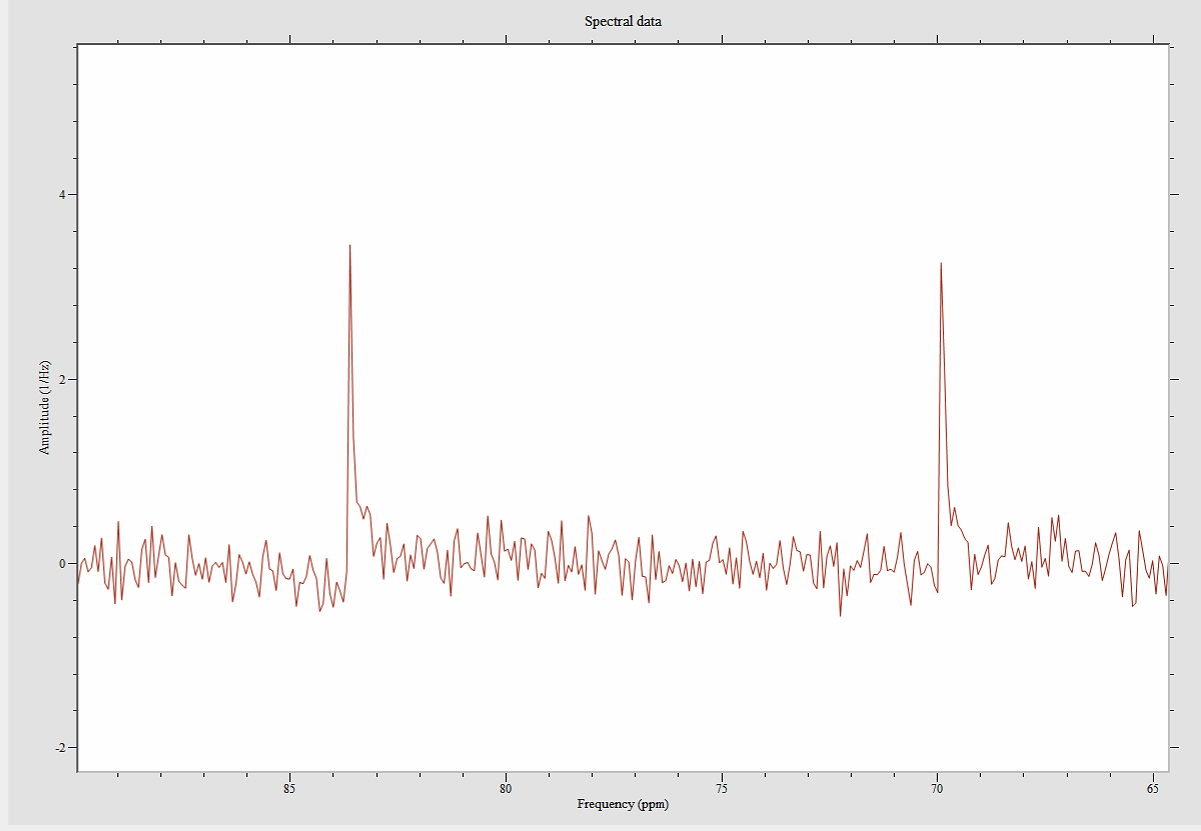

In [ ]:
Image(filename='FID_CHCl3_13C.png',  width=700, height=600)

Questions are:
- Can you identify the peaks?
- How much is the J coupling and does the value agree with the 1H spectra?
- What are the contributing factors for low values of SNR for 13C

## Exp.4) Pulse Length Calibration $^{13}$C

From the Templates menu, save a copy of the "PulseLengthCalib_13C_Template" experiment to your group's menu and write the correct pulse sequence. This program is used to determine the length of a $\pi/2$ pulse for the 13C channel. Since the pulse is going to be much longer than in the 1H case, you should use a larger step size.

How long is the $\pi/2$  pulse on 13C nuclei?


## Exp.5) Polarization transfer & Decoupling

As you have discovered, pulsing directly on carbon nuclei does not produce a very strong signal. Even when samples are enriched with the magnetic ￼$^{13}$C isotope (replacing the nonmagnetic ￼$^{12}$C), the carbon signal—though roughly 100 times stronger than in non-labeled samples—still tends to be weaker than proton signals. To overcome this, NMR makes use of polarization transfer techniques, where the strong polarization of abundant proton spins ($^1$H) is transferred to the less-sensitive carbon spins ($^{13}$C).

Interestingly, the theoretical underpinnings of polarization transfer in NMR parallel certain operations in quantum computing. In particular, the SWAP gate used in quantum circuits to exchange the states of two qubits reflects the same principle of spin-state (or magnetization) exchange found in NMR pulse sequences. In both cases, carefully timed sequences between two qubits (spins) allow one to transfer the “state” (polarization in NMR) from one to the other.

One of the most widely used NMR polarization transfer methods is the Nuclear Overhauser Effect (NOE), which relies on cross-relaxation between the “weak” carbon spins and “strong” proton spins. This effect provides a route for carbon nuclei to gain enhanced magnetization from nearby protons, leading to a stronger carbon signal. Chapter 8 of Keeler’s book (provided in the Lab 2 reading material) offers a comprehensive explanation of relaxation processes and the NOE.

Another way to improve the signal-to-noise ratio (SNR) in carbon-detected experiments is to decouple carbons from their attached protons. Decoupling prevents the carbon resonance from splitting into multiple peaks due to scalar coupling with protons. As a result, you observe a single sharp peak instead of multiple smaller ones, boosting the effective signal. For a more detailed discussion of spin-echo sequences, decoupling, and the associated product operator formalism, please see Chapter 6 of Keeler’s book (this week’s reading material).

Taken together, these techniques—polarization transfer (including the NOE), decoupling strategies, and the conceptual analog to quantum computing’s SWAP gate—demonstrate how controlling spin dynamics is fundamental not only to modern NMR methods but also to the broader field of quantum information science.

Use the "NOE_dec_13C" experiment from the Template menu to observe the 13C spectrum. Note that this time the pulse program is already provided for you, but you can still take a look at it to understand what the program is doing. How much improvement is observed compared to the direct pulse experiment?

## Exp.6) $T_1$ measurement $^{13}$C

To measure the $^{13}$C $T_1$ relaxation time, make a copy of the "T1IR_13C_Template" experiment from the Template menu and save it to your groups directory and add the pulse sequence.

Note that in this experiment, to increase the SNR, the detection is done with 1H spin decoupling. Decoupling is implemented by pulsing the 1H channel with a sequence of 16 $\pi$ pulses, the method is known as WALTZ-16. First report the $T_1$ in the default mode.

An interesting question is that if coupling to 1H affects the $^{13}$C $T_1$ time. To study that, repeat the $T_1$ measurement without turning on the decoupling sequence.

Discuss the value of  $T_1$ observed in both cases.

## Exp.7) Carr-Purcell-Meiboom-Gill or CPMG experiment

The Carr-Purcell-Meiboom-Gill (CPMG) experiment is designed to mitigate dephasing effects caused by static field inhomogeneities and other environmental interactions. Essentially, it applies a train of refocusing (180°) pulses—an extension of the Hahn echo concept—to repeatedly flip the magnetization, rephasing spins that would otherwise dephase over time. By periodically sampling the signal in the middle of these refocusing pulses, one can observe the decay envelope associated with true $T_2$ relaxation (rather than inhomogeneity-based dephasing).

To observe this effect, first spoil the shim (as in last week’s echo experiment) to make the inhomogeneity-induced dephasing more pronounced. Then, use the “CPMG-1H” experiment from the template menu. This sequence implements the following steps:

	1.	Initial Excitation – A 90° pulse excites the spins into the transverse plane.
	2.	Refocusing Pulses – A series of 180° pulses is applied at regular intervals to invert the magnetization and refocus dephasing.
	3.	Data Acquisition – After each refocusing pulse, the instrument briefly opens the receiver and records a single complex data point, capturing the echo amplitude.

In this experiment, Echo Time corresponds to the total delay from the initial 90° pulse to the point of signal acquisition, and Number of Points indicates how many 180° pulses (and corresponding data points) are used in the CPMG train. The pulse program is already configured for you, but you are encouraged to review it to see precisely how the repeated refocusing and data acquisition steps are orchestrated.

By plotting the amplitudes of these echo points against time, you will observe a decay governed by $T_2$ relaxation. From that decay, determine how long $T_2$ is for your sample. How does it compare with the $T_2^*$ before spoiling the shim?